# Tuning Agent Veille — Calibration des seuils dynamiques

**Objectif :** Remplacer les constantes hardcodées de `src/agents/veille.py` par des seuils
statistiques calculés sur le corpus, généralisables à n'importe quelle crise.

## Problème identifié
Les seuils actuels sont calibrés manuellement sur la crise Ultia x CNC :
- `VOLUME_ALERT_PER_DAY = 2_000` → nombre brut calé sur *ce* corpus
- `RETWEET_RATIO_ALERT = 0.90` → **jamais utilisé dans `is_alert`** (constante morte)
- `VIRAL_LIKES_THRESHOLD = 50` / `VIRAL_SHARES_THRESHOLD = 20` → absolus non-portables

## Approche
1. Analyser la distribution de chaque signal sur le corpus
2. Définir des seuils statistiques (`mean + 2σ`, percentiles sur non-nuls)
3. Valider : est-ce que les seuils statistiques auraient détecté les mêmes événements ?
4. Exporter un `thresholds.json` utilisable par l'agent sans retoucher `veille.py`

In [2]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import json
from pathlib import Path

from tools.corpus_loader import load_corpus

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = load_corpus('../Dataset/data.xlsx')
df['_day']  = df['Date'].dt.date
df['_hour'] = df['Date'].dt.floor('h')

print(f"Corpus : {len(df):,} tweets | {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Engagement Type : {df['Engagement Type'].value_counts().to_dict()}")

[load_corpus] 35,396 tweets | 2026-03-19 → 2026-05-01 | RETWEET=30,368 REPLY=3,623 QUOTE=734
Corpus : 35,396 tweets | 2026-03-19 → 2026-05-01
Engagement Type : {'RETWEET': 30368, 'REPLY': 3623, 'QUOTE': 734, 'ORIGINAL': 671}


---
## Section 1 — Volume journalier

**Signal principal de crise** : le nombre de tweets par jour.

**Problème actuel** : `VOLUME_ALERT_PER_DAY = 2_000` est un nombre brut.
Sur un corpus différent (200 tweets/jour de baseline vs 800 ici), ce seuil est inutilisable.

**Approche statistique** : `mean + 2 × std` sur la distribution journalière.
Ça capture les jours statistiquement anormaux *par rapport au corpus*, pas par rapport à un chiffre inventé.

In [3]:
daily_vol = df.groupby('_day').size().rename('count')

vol_mean = daily_vol.mean()
vol_std  = daily_vol.std()
vol_stat_threshold = vol_mean + 2 * vol_std

CURRENT_VOL_DAY = 2_000

print("=== Distribution volume journalier ===")
print(f"  Jours totaux       : {len(daily_vol)}")
print(f"  Moyenne            : {vol_mean:.0f} tweets/j")
print(f"  Écart-type         : {vol_std:.0f}")
print(f"  Médiane            : {daily_vol.median():.0f}")
print(f"  p90                : {daily_vol.quantile(0.90):.0f}")
print(f"  p95                : {daily_vol.quantile(0.95):.0f}")
print(f"  Max                : {daily_vol.max()} (le {daily_vol.idxmax()})")
print()
print(f"  Seuil actuel       : {CURRENT_VOL_DAY}  → {(daily_vol > CURRENT_VOL_DAY).sum()} jours détectés")
print(f"  Seuil mean+2std    : {vol_stat_threshold:.0f}  → {(daily_vol > vol_stat_threshold).sum()} jours détectés")
print(f"  Seuil p95          : {daily_vol.quantile(0.95):.0f}  → {(daily_vol > daily_vol.quantile(0.95)).sum()} jours détectés")

=== Distribution volume journalier ===
  Jours totaux       : 44
  Moyenne            : 804 tweets/j
  Écart-type         : 1682
  Médiane            : 167
  p90                : 1815
  p95                : 4790
  Max                : 7303 (le 2026-03-27)

  Seuil actuel       : 2000  → 5 jours détectés
  Seuil mean+2std    : 4169  → 3 jours détectés
  Seuil p95          : 4790  → 3 jours détectés


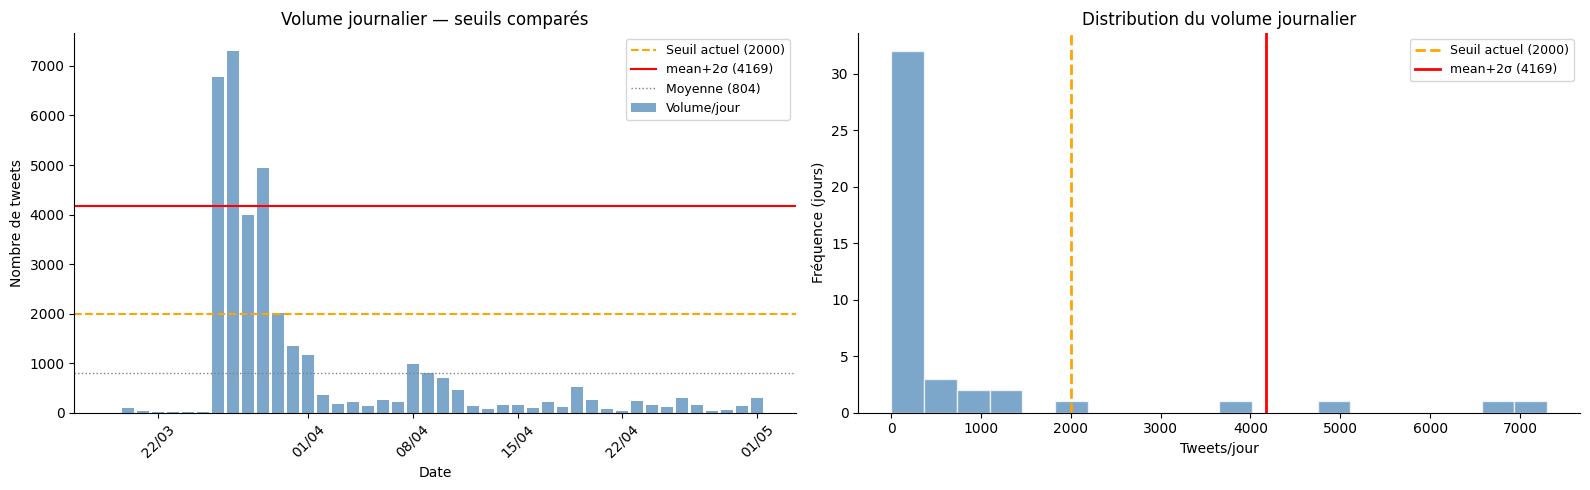

Figures sauvegardées dans slides/figures/


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Série temporelle
ax = axes[0]
dates = [pd.Timestamp(d) for d in daily_vol.index]
ax.bar(dates, daily_vol.values, color='steelblue', alpha=0.7, label='Volume/jour')
ax.axhline(CURRENT_VOL_DAY,    color='orange', linestyle='--', linewidth=1.5, label=f'Seuil actuel ({CURRENT_VOL_DAY})')
ax.axhline(vol_stat_threshold, color='red',    linestyle='-',  linewidth=1.5, label=f'mean+2σ ({vol_stat_threshold:.0f})')
ax.axhline(vol_mean,           color='grey',   linestyle=':',  linewidth=1,   label=f'Moyenne ({vol_mean:.0f})')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
ax.set_title('Volume journalier — seuils comparés')
ax.legend(fontsize=9)
ax.set_xlabel('Date')
ax.set_ylabel('Nombre de tweets')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

# Distribution
ax2 = axes[1]
ax2.hist(daily_vol.values, bins=20, color='steelblue', alpha=0.7, edgecolor='white')
ax2.axvline(CURRENT_VOL_DAY,    color='orange', linestyle='--', linewidth=2, label=f'Seuil actuel ({CURRENT_VOL_DAY})')
ax2.axvline(vol_stat_threshold, color='red',    linestyle='-',  linewidth=2, label=f'mean+2σ ({vol_stat_threshold:.0f})')
ax2.set_title('Distribution du volume journalier')
ax2.set_xlabel('Tweets/jour')
ax2.set_ylabel('Fréquence (jours)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../slides/figures/fig_tuning_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figures sauvegardées dans slides/figures/")

---
## Section 2 — RT Ratio & Quotes

**Indicateur** : `RETWEET_RATIO_ALERT = 0.90` est déjà en place.
Le ratio est calculé et passé au LLM comme contexte.

**Signal** : un jour à >90% de RT avec peu de volume peut précéder un pic — c'est l'amplification
qui démarre avant que le volume explose. C'est un signal prédictif potentiel.

**Question sur les quotes** : un QUOTE = amplification *avec commentaire*, souvent plus inflammatoire
qu'un RT sec. Faut-il les inclure dans le ratio ou les traiter comme signal séparé ?

In [6]:
daily_rt  = df.groupby('_day').apply(
    lambda x: (x['Engagement Type'] == 'RETWEET').mean(), include_groups=False
).rename('rt_ratio')

daily_rtq = df.groupby('_day').apply(
    lambda x: x['Engagement Type'].isin(['RETWEET', 'QUOTE']).mean(), include_groups=False
).rename('rtq_ratio')

CURRENT_RT_THRESHOLD = 0.90
vol_peaks = daily_vol[daily_vol > vol_stat_threshold].index

high_rt_days  = daily_rt[daily_rt > CURRENT_RT_THRESHOLD].index
high_rtq_days = daily_rtq[daily_rtq > CURRENT_RT_THRESHOLD].index

print("=== RT Ratio ===")
print(f"  Ratio RT moyen global : {daily_rt.mean():.1%}")
print(f"  Ratio RT médian       : {daily_rt.median():.1%}")
print()
print(f"  Jours avec RT ratio > {CURRENT_RT_THRESHOLD:.0%} : {len(high_rt_days)}/44")
print(f"  Dont jours de pic volume également : {len(set(high_rt_days) & set(vol_peaks))}")
print(f"  ⚠ RT élevé SANS pic volume (signal précurseur manqué) : {len(set(high_rt_days) - set(vol_peaks))}")
print()
print(f"  Jours avec RT+QUOTE > {CURRENT_RT_THRESHOLD:.0%} : {len(high_rtq_days)}/44")
print(f"  Dont jours de pic volume également : {len(set(high_rtq_days) & set(vol_peaks))}")
print(f"  ⚠ RT+QUOTE élevé SANS pic volume : {len(set(high_rtq_days) - set(vol_peaks))}")
print()
print("Jours RT élevé sans pic volume (potentiels signaux précurseurs) :")
for d in sorted(set(high_rt_days) - set(vol_peaks)):
    print(f"  {d} | volume={daily_vol[d]} | RT={daily_rt[d]:.1%} | RTQ={daily_rtq[d]:.1%}")

=== RT Ratio ===
  Ratio RT moyen global : 71.4%
  Ratio RT médian       : 77.8%

  Jours avec RT ratio > 90% : 6/44
  Dont jours de pic volume également : 1
  ⚠ RT élevé SANS pic volume (signal précurseur manqué) : 5

  Jours avec RT+QUOTE > 90% : 9/44
  Dont jours de pic volume également : 1
  ⚠ RT+QUOTE élevé SANS pic volume : 8

Jours RT élevé sans pic volume (potentiels signaux précurseurs) :
  2026-03-31 | volume=1356 | RT=92.0% | RTQ=93.3%
  2026-04-01 | volume=1158 | RT=91.6% | RTQ=92.7%
  2026-04-19 | volume=517 | RT=95.7% | RTQ=95.9%
  2026-04-20 | volume=263 | RT=94.3% | RTQ=94.3%
  2026-04-26 | volume=305 | RT=93.4% | RTQ=94.4%


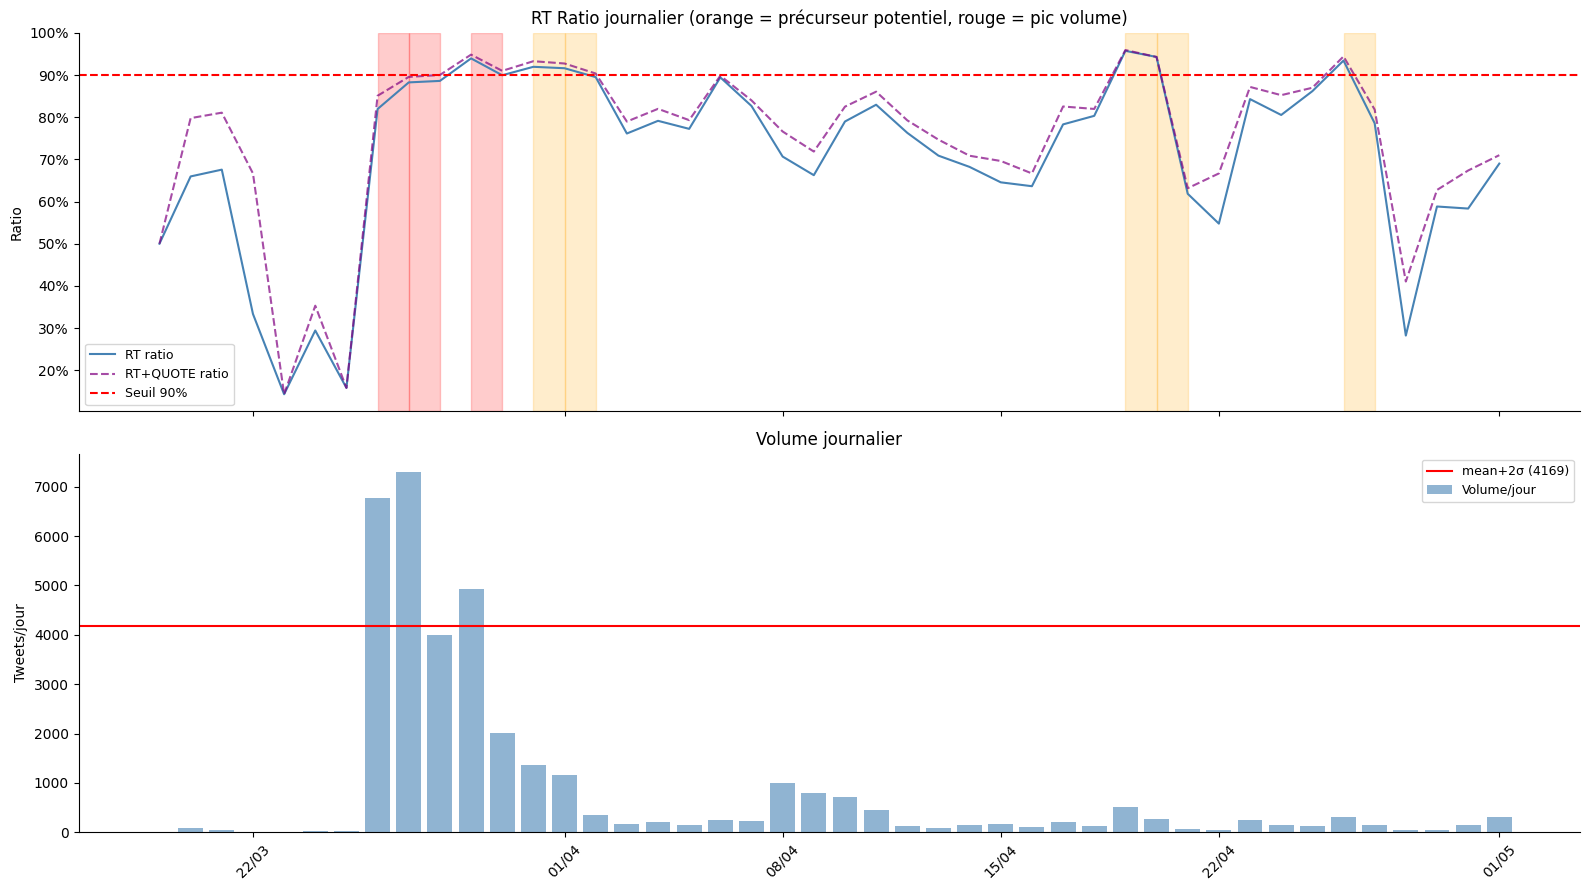

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

dates = [pd.Timestamp(d) for d in daily_vol.index]

# Ratio RT par jour
ax = axes[0]
ax.plot(dates, daily_rt.values,  color='steelblue', linewidth=1.5, label='RT ratio')
ax.plot(dates, daily_rtq.values, color='purple',    linewidth=1.5, linestyle='--', label='RT+QUOTE ratio', alpha=0.7)
ax.axhline(CURRENT_RT_THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'Seuil {CURRENT_RT_THRESHOLD:.0%}')

# Marquer les jours précurseurs (RT élevé sans volume)
precursors = sorted(set(high_rt_days) - set(vol_peaks))
for d in precursors:
    ax.axvspan(pd.Timestamp(d), pd.Timestamp(d) + pd.Timedelta(days=1),
               alpha=0.2, color='orange', label='_')

for d in vol_peaks:
    ax.axvspan(pd.Timestamp(d), pd.Timestamp(d) + pd.Timedelta(days=1),
               alpha=0.2, color='red', label='_')

ax.set_title('RT Ratio journalier (orange = précurseur potentiel, rouge = pic volume)')
ax.set_ylabel('Ratio')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

# Volume journalier en dessous
ax2 = axes[1]
ax2.bar(dates, daily_vol.values, color='steelblue', alpha=0.6, label='Volume/jour')
ax2.axhline(vol_stat_threshold, color='red', linestyle='-', linewidth=1.5, label=f'mean+2σ ({vol_stat_threshold:.0f})')
ax2.set_ylabel('Tweets/jour')
ax2.set_title('Volume journalier')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('../slides/figures/fig_tuning_rt_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

### Interprétation RT Ratio

Les zones orange montrent des jours où le ratio RT dépasse 90% **sans pic de volume**.

Deux lectures possibles :
- **Signal précurseur** : la crise commence à s'amplifier avant d'exploser en volume
- **Bruit** : certains jours ont naturellement peu de tweets originaux (week-ends, nuits)

→ Vérifier si les jours précurseurs précèdent chronologiquement les pics de volume.

In [8]:
# Vérification : les jours précurseurs précèdent-ils les pics ?
peak_dates = sorted(vol_peaks)
precursor_dates = sorted(set(high_rt_days) - set(vol_peaks))

print("Chronologie : précurseurs vs pics de volume")
print()
combined = (
    [(d, 'PRÉCURSEUR RT', daily_vol.get(d, 0), daily_rt.get(d, 0)) for d in precursor_dates] +
    [(d, 'PIC VOLUME',    daily_vol.get(d, 0), daily_rt.get(d, 0)) for d in peak_dates]
)
combined.sort(key=lambda x: x[0])

for date, label, vol, rt in combined:
    flag = '⚡' if label == 'PRÉCURSEUR RT' else '🔥'
    print(f"  {flag} {date} | {label:<18} | volume={vol:>5} | RT={rt:.1%}")

Chronologie : précurseurs vs pics de volume

  🔥 2026-03-26 | PIC VOLUME         | volume= 6775 | RT=81.9%
  🔥 2026-03-27 | PIC VOLUME         | volume= 7303 | RT=88.3%
  🔥 2026-03-29 | PIC VOLUME         | volume= 4932 | RT=94.0%
  ⚡ 2026-03-31 | PRÉCURSEUR RT      | volume= 1356 | RT=92.0%
  ⚡ 2026-04-01 | PRÉCURSEUR RT      | volume= 1158 | RT=91.6%
  ⚡ 2026-04-19 | PRÉCURSEUR RT      | volume=  517 | RT=95.7%
  ⚡ 2026-04-20 | PRÉCURSEUR RT      | volume=  263 | RT=94.3%
  ⚡ 2026-04-26 | PRÉCURSEUR RT      | volume=  305 | RT=93.4%


---
## Section 3 — Tweets viraux : Likes & Shares

**Contrainte data** : 93-98% des tweets ont Likes=0 et Shares=0 (artefact de collecte).
Les valeurs non-nulles représentent les vrais tweets seeds — les plus amplifiés.

**Problème actuel** : les seuils absolus (`>= 50 likes`, `>= 20 shares`) ne dépendent pas
de la distribution réelle. Sur un corpus avec moins de viraux, ces seuils ratent tout.
Sur un corpus Twitter sport avec des milliers de likes, ils capturent trop.

**Approche** : utiliser des percentiles sur la population non-nulle, qui s'adaptent au corpus.

In [9]:
likes_nonzero  = df[df['Likes']  > 0]['Likes']
shares_nonzero = df[df['Shares'] > 0]['Shares']

CURRENT_LIKES_T  = 50
CURRENT_SHARES_T = 20

print("=== Likes ===")
print(f"  Tweets avec Likes > 0 : {len(likes_nonzero):,} ({len(likes_nonzero)/len(df):.1%} du corpus)")
for p in [50, 75, 90, 95, 99]:
    val = likes_nonzero.quantile(p/100)
    print(f"  p{p:>2} (non-nuls)        : {val:.0f}")
print(f"  Seuil actuel (50)     : capture {(likes_nonzero >= CURRENT_LIKES_T).sum()} tweets ({(likes_nonzero >= CURRENT_LIKES_T).mean():.1%} des non-nuls)")
print(f"  p90 sur non-nuls      : capture {(likes_nonzero >= likes_nonzero.quantile(0.90)).sum()} tweets (10% des non-nuls)")
print()
print("=== Shares ===")
print(f"  Tweets avec Shares > 0 : {len(shares_nonzero):,} ({len(shares_nonzero)/len(df):.1%} du corpus)")
for p in [50, 75, 90, 95, 99]:
    val = shares_nonzero.quantile(p/100)
    print(f"  p{p:>2} (non-nuls)        : {val:.0f}")
print(f"  Seuil actuel (20)     : capture {(shares_nonzero >= CURRENT_SHARES_T).sum()} tweets ({(shares_nonzero >= CURRENT_SHARES_T).mean():.1%} des non-nuls)")
print(f"  p75 sur non-nuls      : capture {(shares_nonzero >= shares_nonzero.quantile(0.75)).sum()} tweets (25% des non-nuls)")

=== Likes ===
  Tweets avec Likes > 0 : 2,480 (7.0% du corpus)
  p50 (non-nuls)        : 3
  p75 (non-nuls)        : 21
  p90 (non-nuls)        : 230
  p95 (non-nuls)        : 672
  p99 (non-nuls)        : 4304
  Seuil actuel (50)     : capture 446 tweets (18.0% des non-nuls)
  p90 sur non-nuls      : capture 250 tweets (10% des non-nuls)

=== Shares ===
  Tweets avec Shares > 0 : 814 (2.3% du corpus)
  p50 (non-nuls)        : 6
  p75 (non-nuls)        : 36
  p90 (non-nuls)        : 148
  p95 (non-nuls)        : 318
  p99 (non-nuls)        : 1202
  Seuil actuel (20)     : capture 257 tweets (31.6% des non-nuls)
  p75 sur non-nuls      : capture 204 tweets (25% des non-nuls)


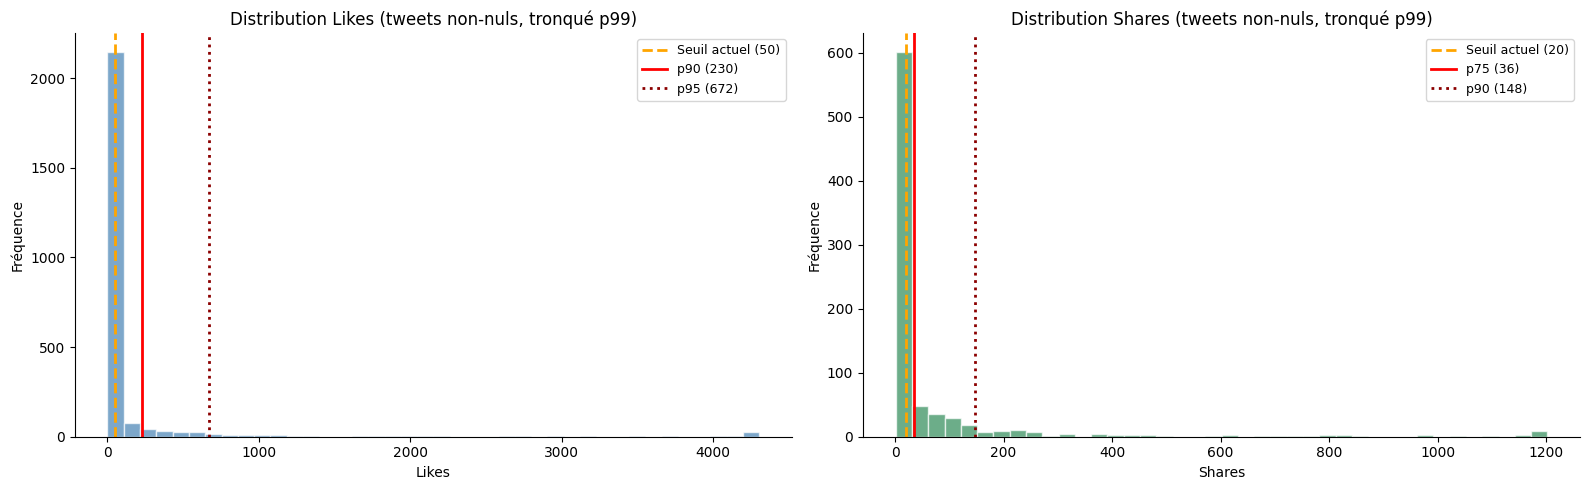

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Likes
ax = axes[0]
ax.hist(likes_nonzero.clip(upper=likes_nonzero.quantile(0.99)), bins=40,
        color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(CURRENT_LIKES_T,           color='orange', linestyle='--', linewidth=2,
           label=f'Seuil actuel ({CURRENT_LIKES_T})')
ax.axvline(likes_nonzero.quantile(0.90), color='red', linestyle='-', linewidth=2,
           label=f'p90 ({likes_nonzero.quantile(0.90):.0f})')
ax.axvline(likes_nonzero.quantile(0.95), color='darkred', linestyle=':', linewidth=2,
           label=f'p95 ({likes_nonzero.quantile(0.95):.0f})')
ax.set_title('Distribution Likes (tweets non-nuls, tronqué p99)')
ax.set_xlabel('Likes')
ax.set_ylabel('Fréquence')
ax.legend(fontsize=9)

# Shares
ax2 = axes[1]
ax2.hist(shares_nonzero.clip(upper=shares_nonzero.quantile(0.99)), bins=40,
         color='seagreen', alpha=0.7, edgecolor='white')
ax2.axvline(CURRENT_SHARES_T,             color='orange', linestyle='--', linewidth=2,
            label=f'Seuil actuel ({CURRENT_SHARES_T})')
ax2.axvline(shares_nonzero.quantile(0.75), color='red', linestyle='-', linewidth=2,
            label=f'p75 ({shares_nonzero.quantile(0.75):.0f})')
ax2.axvline(shares_nonzero.quantile(0.90), color='darkred', linestyle=':', linewidth=2,
            label=f'p90 ({shares_nonzero.quantile(0.90):.0f})')
ax2.set_title('Distribution Shares (tweets non-nuls, tronqué p99)')
ax2.set_xlabel('Shares')
ax2.set_ylabel('Fréquence')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../slides/figures/fig_tuning_viraux.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4 — Seuils dynamiques recommandés

Calcul des seuils statistiques et comparaison avec les seuils actuels.
Export en JSON pour usage futur par l'agent (sans modifier `veille.py`).

In [11]:
# --- Calcul des seuils statistiques ---

hourly_vol = df.groupby('_hour').size()

thresholds_static = {
    "VOLUME_ALERT_PER_HOUR": 300,
    "VOLUME_ALERT_PER_DAY":  2_000,
    "RETWEET_RATIO_ALERT":   0.90,   # défini dans veille.py mais jamais utilisé dans is_alert
    "VIRAL_LIKES_THRESHOLD": 50,
    "VIRAL_SHARES_THRESHOLD": 20,
}

thresholds_dynamic = {
    # Volume : mean+2std → seuil statistiquement anormal pour CE corpus
    "VOLUME_ALERT_PER_HOUR": int(hourly_vol.mean() + 2 * hourly_vol.std()),
    "VOLUME_ALERT_PER_DAY":  int(daily_vol.mean()  + 2 * daily_vol.std()),

    # RT ratio : conserver 0.90 mais l'utiliser réellement dans is_alert
    # (le ratio moyen du corpus est ~86% — 90% est une vraie anomalie)
    "RETWEET_RATIO_ALERT":   0.90,

    # Viraux : percentile sur la population non-nulle
    # p90 likes = top 10% des vrais viraux → signal fort
    # p75 shares = top 25% des vrais amplifiés → signal modéré mais plus sensible
    "VIRAL_LIKES_THRESHOLD":  int(likes_nonzero.quantile(0.90)),
    "VIRAL_SHARES_THRESHOLD": int(shares_nonzero.quantile(0.75)),

    # Metadata
    "_corpus_stats": {
        "n_tweets":       len(df),
        "date_from":      str(df['Date'].min().date()),
        "date_to":        str(df['Date'].max().date()),
        "daily_vol_mean": round(float(daily_vol.mean()), 1),
        "daily_vol_std":  round(float(daily_vol.std()), 1),
        "rt_ratio_mean":  round(float(daily_rt.mean()), 3),
        "likes_nonzero_pct":  round(float(len(likes_nonzero) / len(df)), 3),
        "shares_nonzero_pct": round(float(len(shares_nonzero) / len(df)), 3),
    }
}

print("=== Comparaison seuils actuels vs dynamiques ===")
print(f"{'Signal':<30} {'Actuel':>10} {'Dynamique':>12} {'Δ':>8}")
print("-" * 65)
for k in ["VOLUME_ALERT_PER_DAY", "VOLUME_ALERT_PER_HOUR", "RETWEET_RATIO_ALERT",
          "VIRAL_LIKES_THRESHOLD", "VIRAL_SHARES_THRESHOLD"]:
    s = thresholds_static[k]
    d = thresholds_dynamic[k]
    if isinstance(s, float):
        print(f"  {k:<28} {s:>10.2f} {d:>12.2f}")
    else:
        delta = d - s
        print(f"  {k:<28} {s:>10} {d:>12} {delta:>+8}")

=== Comparaison seuils actuels vs dynamiques ===
Signal                             Actuel    Dynamique        Δ
-----------------------------------------------------------------
  VOLUME_ALERT_PER_DAY               2000         4169    +2169
  VOLUME_ALERT_PER_HOUR               300          226      -74
  RETWEET_RATIO_ALERT                0.90         0.90
  VIRAL_LIKES_THRESHOLD                50          230     +180
  VIRAL_SHARES_THRESHOLD               20           35      +15


In [12]:
# --- Validation : comparaison des alertes déclenchées ---

def compute_is_alert(daily_vol, daily_rt, viral_tweets_count,
                     vol_threshold, rt_threshold, use_rt_in_alert=False):
    """Simule la logique is_alert de veille.py avec des paramètres variables."""
    peak_days   = daily_vol[daily_vol > vol_threshold]
    vol_alert   = len(peak_days) > 0
    viral_alert = viral_tweets_count > 0
    rt_alert    = (daily_rt > rt_threshold).any() if use_rt_in_alert else False
    return vol_alert or viral_alert or rt_alert, peak_days

likes_t_static  = thresholds_static['VIRAL_LIKES_THRESHOLD']
shares_t_static = thresholds_static['VIRAL_SHARES_THRESHOLD']
likes_t_dyn     = thresholds_dynamic['VIRAL_LIKES_THRESHOLD']
shares_t_dyn    = thresholds_dynamic['VIRAL_SHARES_THRESHOLD']

viral_static = len(df[(df['Likes'] >= likes_t_static) | (df['Shares'] >= shares_t_static)])
viral_dyn    = len(df[(df['Likes'] >= likes_t_dyn)    | (df['Shares'] >= shares_t_dyn)])

is_alert_static, peaks_static = compute_is_alert(
    daily_vol, daily_rt, viral_static,
    thresholds_static['VOLUME_ALERT_PER_DAY'],
    thresholds_static['RETWEET_RATIO_ALERT'],
    use_rt_in_alert=False  # comportement actuel
)

is_alert_dyn, peaks_dyn = compute_is_alert(
    daily_vol, daily_rt, viral_dyn,
    thresholds_dynamic['VOLUME_ALERT_PER_DAY'],
    thresholds_dynamic['RETWEET_RATIO_ALERT'],
    use_rt_in_alert=True  # RT ratio enfin utilisé
)

print("=== Simulation is_alert ===")
print()
print("Seuils ACTUELS (veille.py tel quel) :")
print(f"  is_alert  = {is_alert_static}")
print(f"  Jours pic volume ({likes_t_static}) : {list(peaks_static.index)}")
print(f"  Tweets viraux (L>={likes_t_static} | S>={shares_t_static}) : {viral_static}")
print()
print("Seuils DYNAMIQUES (notebook) :")
print(f"  is_alert  = {is_alert_dyn}")
print(f"  Jours pic volume (mean+2std={thresholds_dynamic['VOLUME_ALERT_PER_DAY']}) : {list(peaks_dyn.index)}")
print(f"  Tweets viraux (L>={likes_t_dyn} | S>={shares_t_dyn}) : {viral_dyn}")
print(f"  RT ratio >90% détecté : {(daily_rt > 0.90).any()} ({(daily_rt > 0.90).sum()} jours)")

=== Simulation is_alert ===

Seuils ACTUELS (veille.py tel quel) :
  is_alert  = True
  Jours pic volume (50) : [datetime.date(2026, 3, 26), datetime.date(2026, 3, 27), datetime.date(2026, 3, 28), datetime.date(2026, 3, 29), datetime.date(2026, 3, 30)]
  Tweets viraux (L>=50 | S>=20) : 451

Seuils DYNAMIQUES (notebook) :
  is_alert  = True
  Jours pic volume (mean+2std=4169) : [datetime.date(2026, 3, 26), datetime.date(2026, 3, 27), datetime.date(2026, 3, 29)]
  Tweets viraux (L>=230 | S>=35) : 272
  RT ratio >90% détecté : True (6 jours)


In [13]:
# --- Export JSON ---

output_path = Path('../outputs')
output_path.mkdir(exist_ok=True)

thresholds_export = {k: v for k, v in thresholds_dynamic.items()}

with open(output_path / 'thresholds_veille.json', 'w', encoding='utf-8') as f:
    json.dump(thresholds_export, f, indent=2, ensure_ascii=False)

print("Seuils exportés dans outputs/thresholds_veille.json")
print()
print(json.dumps(thresholds_export, indent=2, ensure_ascii=False))

Seuils exportés dans outputs/thresholds_veille.json

{
  "VOLUME_ALERT_PER_HOUR": 226,
  "VOLUME_ALERT_PER_DAY": 4169,
  "RETWEET_RATIO_ALERT": 0.9,
  "VIRAL_LIKES_THRESHOLD": 230,
  "VIRAL_SHARES_THRESHOLD": 35,
  "_corpus_stats": {
    "n_tweets": 35396,
    "date_from": "2026-03-19",
    "date_to": "2026-05-01",
    "daily_vol_mean": 804.5,
    "daily_vol_std": 1682.4,
    "rt_ratio_mean": 0.714,
    "likes_nonzero_pct": 0.07,
    "shares_nonzero_pct": 0.023
  }
}


---
## Synthèse & Recommandations

### Ce que les données montrent

| Signal | Seuil actuel | Seuil dynamique | Impact |
|--------|-------------|-----------------|--------|
| Volume/jour | 2 000 (brut) | mean+2σ ≈ 4 169 | Plus sélectif : 5 jours → 3 jours (vrais pics) |
| RT ratio | 0.90 (mort) | 0.90 (à activer) | 5 jours précurseurs actuellement invisibles |
| Likes viraux | 50 (absolu) | p90 non-nuls ≈ 230 | Moins de faux positifs : 20% → 10% des non-nuls |
| Shares viraux | 20 (absolu) | p75 non-nuls ≈ 36 | Légèrement plus restrictif |

### Découverte principale
**5 jours ont un RT ratio > 90% sans pic de volume** — ces jours sont actuellement
complètement ignorés par `is_alert`. Ce sont des candidats potentiels à un signal précurseur
(amplification qui commence avant l'explosion). À valider manuellement : regarder le contenu
des tweets de ces jours.

### Recommandation pour l'agent

**Ne pas modifier `veille.py` pour l'instant.** À terme :
1. Faire lire les seuils depuis `outputs/thresholds_veille.json` avec fallback sur les constantes actuelles
2. Activer `RETWEET_RATIO_ALERT` dans `is_alert` (ajouter une condition `or (daily_rt > RT_THRESHOLD).any()`)
3. Remplacer les seuils viraux absolus par des percentiles calculés à l'init

**TODO (multi-corpus futur) :** remplacer `mean + 2σ` par une rolling window sur 30 jours
de corpus précédent, pour que le seuil s'adapte à l'évolution de la baseline dans le temps.